In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Books.csv")

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13715 entries, 0 to 13714
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               13715 non-null  int64  
 1   Name             13715 non-null  object 
 2   RatingDist1      13714 non-null  object 
 3   pagesNumber      13714 non-null  float64
 4   RatingDist4      13714 non-null  object 
 5   RatingDistTotal  13714 non-null  object 
 6   PublishMonth     13714 non-null  float64
 7   PublishDay       13714 non-null  float64
 8   Publisher        13612 non-null  object 
 9   CountsOfReview   13714 non-null  float64
 10  PublishYear      13714 non-null  float64
 11  Language         5742 non-null   object 
 12  Authors          13714 non-null  object 
 13  Rating           13714 non-null  float64
 14  RatingDist2      13714 non-null  object 
 15  RatingDist5      13714 non-null  object 
 16  ISBN             13509 non-null  object 
 17  RatingDist3 

,Id,pagesNumber,PublishMonth,PublishDay,CountsOfReview,PublishYear,Rating
count,13715.000000,13714.000000,13714.000000,13714.000000,13714.000000,13714.000000,13714.000000
mean,11336.319358,295.344976,10.532813,6.532667,333.378081,1999.749818,3.759609
std,6692.323365,298.910184,10.247978,3.520956,2106.131590,8.139905,0.858601
min,1.000000,0.000000,1.000000,1.000000,0.000000,1900.000000,0.000000
25%,5505.500000,162.000000,1.000000,4.000000,1.000000,1997.000000,3.680000
50%,11268.000000,256.000000,7.000000,7.000000,8.000000,2002.000000,3.930000
75%,17047.500000,369.750000,18.000000,10.000000,65.000000,2005.000000,4.140000
max,23205.000000,23931.000000,31.000000,12.000000,87685.000000,2019.000000,5.000000


In [ ]:
df.isnull()

,Id,Name,RatingDist1,pagesNumber,RatingDist4,RatingDistTotal,PublishMonth,PublishDay,Publisher,CountsOfReview,PublishYear,Language,Authors,Rating,RatingDist2,RatingDist5,ISBN,RatingDist3
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13710,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13711,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13712,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
13713,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Id,0
Name,0
RatingDist1,1
pagesNumber,1
RatingDist4,1
RatingDistTotal,1
PublishMonth,1
PublishDay,1
Publisher,103
CountsOfReview,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.corr(numeric_only=True)["Rating"].sort_values(ascending=False)

,Rating
Rating,1.000000
pagesNumber,0.158659
PublishDay,0.045859
CountsOfReview,0.031757
Id,0.001135
PublishMonth,-0.009132
PublishYear,-0.050853


In [ ]:
df.isnull().sum()

,0
Id,0
Name,0
RatingDist1,0
pagesNumber,0
RatingDist4,0
RatingDistTotal,0
PublishMonth,0
PublishDay,0
Publisher,0
CountsOfReview,0


In [ ]:
df["RatingDist1"].head(10)

,RatingDist1
1,1:12455
3,1:11896
4,1:10128
6,1:402
7,1:0
8,1:257
9,1:3443
10,1:3443
11,1:28636
12,1:3443


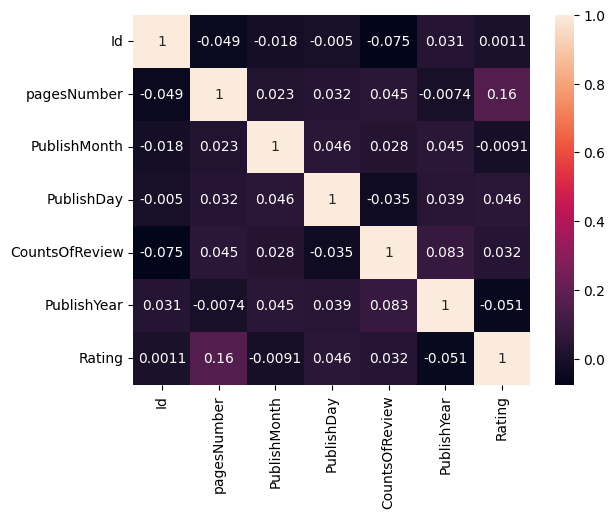

In [ ]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.show()

**converting object into int**

In [ ]:
df["RatingDist1"]=df["RatingDist1"].str.split(":").str[1].astype(int)

In [ ]:
df["RatingDist2"] = df["RatingDist2"].str.split(":").str[1].astype(int)

Loop

In [ ]:
cols=[
    "RatingDist3",
    "RatingDist4",
    "RatingDist5",
    "RatingDistTotal"
]
for col in cols:
    df[col]=df[col].str.split(":").str[1].astype(int)

In [ ]:
for col in cols:
  print(df[col].dtype)

int64
int64
int64
int64


**Checking**

In [ ]:
for col in [
    "RatingDist1",
    "RatingDist2",
    "RatingDist3",
    "RatingDist4",
    "RatingDist5",
    "RatingDistTotal"
]:
  print(df[col].dtype)

int64
int64
int64
int64
int64
int64


In [ ]:
x=df[
    [
        "RatingDist1",
        "RatingDist2",
        "RatingDist3",
        "RatingDist4",
        "RatingDist5",
        "RatingDistTotal",
        "CountsOfReview"
    ]
]

In [ ]:
print(x.dtypes)

RatingDist1          int64
RatingDist2          int64
RatingDist3          int64
RatingDist4          int64
RatingDist5          int64
RatingDistTotal      int64
CountsOfReview     float64
dtype: object


In [ ]:
y=df["Rating"]#Select Target (y)
#Because Rating is a continuous number (4.2, 4.5, 3.9), \\
#which is perfect for Linear Regression.

In [ ]:
x.shape

(5564, 7)

In [ ]:
y.shape

(5564,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_predict=model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_predict)
print(r2)

0.0014051829255027348


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(mean_absolute_error(y_test,y_predict))
print(mean_squared_error(y_test,y_predict))

0.23388048880356596
0.1413497290587152


In [ ]:
x.head()

,RatingDist1,RatingDist2,RatingDist3,RatingDist4,RatingDist5,RatingDistTotal,CountsOfReview
1,12455,37005,211781,604283,1493113,2358637,29770.0
3,11896,49353,288821,706082,1504505,2560657,244.0
4,10128,24849,194848,630534,1749958,2610317,37093.0
6,402,283,1201,4650,37432,43968,166.0
7,0,5,6,7,10,28,1.0


In [ ]:
print(y_test)
print(y_predict)

1476     3.67
6701     4.03
7412     4.32
4235     4.31
9702     4.23
         ... 
11261    4.48
11091    3.98
3223     3.74
8428     4.22
9574     4.07
Name: Rating, Length: 1113, dtype: float64
[3.94252671 3.94647724 3.94280791 ... 3.91197238 3.9700682  3.95271514]


In [ ]:
print(x.columns)

Index(['RatingDist1', 'RatingDist2', 'RatingDist3', 'RatingDist4',
       'RatingDist5', 'RatingDistTotal', 'CountsOfReview'],
      dtype='object')


In [ ]:
df.corr(numeric_only=True)["Rating"].sort_values(ascending=False)

,Rating
Rating,1.000000
pagesNumber,0.158659
RatingDist5,0.101814
RatingDistTotal,0.076183
RatingDist4,0.070674
PublishDay,0.045859
CountsOfReview,0.031757
RatingDist3,0.023878
Id,0.001135
RatingDist1,-0.003621


In [ ]:
df.columns

Index(['Id', 'Name', 'RatingDist1', 'pagesNumber', 'RatingDist4',
       'RatingDistTotal', 'PublishMonth', 'PublishDay', 'Publisher',
       'CountsOfReview', 'PublishYear', 'Language', 'Authors', 'Rating',
       'RatingDist2', 'RatingDist5', 'ISBN', 'RatingDist3'],
      dtype='object')

In [ ]:
df.corr(numeric_only=True)["Rating"].sort_values(ascending=False)

,Rating
Rating,1.000000
pagesNumber,0.158659
RatingDist5,0.101814
RatingDistTotal,0.076183
RatingDist4,0.070674
PublishDay,0.045859
CountsOfReview,0.031757
RatingDist3,0.023878
Id,0.001135
RatingDist1,-0.003621


In [ ]:
#print(y_test.head(10))
#print(y_predict(10))
result=pd.DataFrame(
    {
        "Actual":y_test,
        "Predicted":y_predict
    }
)
result

,Actual,Predicted
1476,3.67,3.942527
6701,4.03,3.946477
7412,4.32,3.942808
4235,4.31,3.943723
9702,4.23,3.996215
...,...,...
11261,4.48,3.942787
11091,3.98,3.942585
3223,3.74,3.911972
8428,4.22,3.970068


##WHY THE MODEL FAILED
# Why My Linear Regression Model Failed on the Book Dataset

## Problem

I tried to predict:

```python
y = Rating
```

using:

```python
X = [
    "pagesNumber",
    "CountsOfReview",
    "PublishYear"
]
```

After training and testing the model, I got:

```python
R² = 0.0014
```

which is extremely low.

---

## Evidence

Actual values:

```text
3.67
4.03
4.32
4.31
4.23
```

Predicted values:

```text
3.94
3.94
3.94
3.94
3.99
```

The model keeps predicting nearly the same number.

---

## Why This Happened

The selected features have almost no relationship with the target column.

Correlation with Rating:

```text
pagesNumber      0.15
CountsOfReview   0.03
PublishYear     -0.05
```

These values are very close to zero.

This means:

- Number of pages does not strongly affect rating.
- Number of reviews does not strongly affect rating.
- Publish year does not strongly affect rating.

Therefore, the model cannot learn a useful pattern.

---

## What the Model Did

Since it could not find a relationship, the model started predicting values close to the average rating.

Example:

```python
df["Rating"].mean()
```

Suppose average rating is:

```text
3.94
```

The model then predicts:

```text
3.94
3.95
3.93
3.94
3.96
```

for almost every book.

This is called:

> Predicting the mean of the target variable.

---

## Why Predictions Look Similar

Bad model:

```text
Book A -> 3.94
Book B -> 3.95
Book C -> 3.94
Book D -> 3.93
```

Good model:

```text
Book A -> 4.50
Book B -> 3.20
Book C -> 4.10
Book D -> 2.80
```

A good model produces different predictions because it finds patterns in the features.

My model could not find such patterns.

---

## Meaning of R²

R² measures how much variation in the target variable is explained by the features.

Formula:

```text
R² = 1 - (SS_res / SS_total)
```

Where:

- SS_res = prediction error
- SS_total = total variation in actual values

---

## R² Interpretation Table

| R² Value | Meaning |
|-----------|----------|
| 1.0 | Perfect prediction |
| 0.9+ | Excellent |
| 0.7 - 0.9 | Good |
| 0.5 - 0.7 | Acceptable |
| 0.3 - 0.5 | Weak |
| 0.0 - 0.3 | Very Poor |
| 0.0014 | Almost no predictive power |

---

## Comparison with Salary Dataset

Salary Dataset:

```python
YearsOfExperience -> Salary
```

Strong relationship:

```text
More Experience → Higher Salary
```

Result:

```python
R² ≈ 0.65
```

Book Dataset:

```python
Pages + Reviews + PublishYear -> Rating
```

Weak relationship:

```python
R² ≈ 0.0014
```

---

## Final Conclusion

The Linear Regression algorithm is working correctly.

The problem is not the model.

The problem is that the selected features:

```python
pagesNumber
CountsOfReview
PublishYear
```

do not contain enough information to predict:

```python
Rating
```

As a result, the model predicts values close to the average rating and achieves an extremely low R² score.